# STATS19 Yorkshire — Systematic BNG Coordinate Error

**Prepared for:** DfT Road Safety Statistics Team / ropensci/stats19 maintainers  
**Date:** April 2026  

---

## Summary

All Yorkshire STATS19 collisions (police forces 12, 13, 14, 16) across 2015–2024 have a **systematic BNG grid letter error**. The `location_easting_osgr` values are consistently ~100–200km too far west, placing collisions in Lancashire rather than Yorkshire. The `longitude`/`latitude` fields — being derived from BNG — are therefore also wrong.

This notebook uses **only publicly available DfT data** — the STATS19 CSV and the published data guide Excel — with no external dependencies beyond standard Python libraries.

### Key evidence: internal inconsistency in DfT's own data

A collision with `local_authority_ons_district = Leeds` (E08000035) should have coordinates near Leeds (lat ~53.80, lon ~-1.55). In the raw data, these collisions have coordinates placing them near Rochdale (lat ~53.6, lon ~-2.1) — over 40km from their attributed district.

This inconsistency is verifiable using only the STATS19 CSV and the published data guide, with no external data required.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pyproj

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
BNG_TO_WGS84 = pyproj.Transformer.from_crs('EPSG:27700', 'EPSG:4326', always_xy=True)

# ── UPDATE THESE PATHS ────────────────────────────────────────────────────────
STATS19_CSV = Path('../data/raw/stats19/dft-road-casualty-statistics-collision-1979-latest-published-year.csv')
DATA_GUIDE  = Path('../data/raw/stats19/dft-road-casualty-statistics-road-safety-open-dataset-data-guide-2024.xlsx')
# ──────────────────────────────────────────────────────────────────────────────

# Yorkshire ONS district approximate centroids (WGS84)
# Source: ONS Open Geography Portal — Local Authority Districts Dec 2023
YORKSHIRE_DISTRICT_CENTROIDS = {
    'E06000010': ('Hull',              53.745, -0.336),
    'E06000011': ('East Riding',       53.842,  0.034),
    'E06000014': ('York',              53.958, -1.081),
    'E06000065': ('North Yorkshire',   54.160, -1.480),
    'E07000163': ('Craven',            54.012, -2.174),
    'E07000164': ('Hambleton',         54.237, -1.355),
    'E07000165': ('Harrogate',         54.000, -1.540),
    'E07000166': ('Richmondshire',     54.404, -1.724),
    'E07000167': ('Ryedale',           54.131, -0.830),
    'E07000168': ('Scarborough',       54.280, -0.401),
    'E07000169': ('Selby',             53.779, -1.070),
    'E08000016': ('Barnsley',          53.553, -1.479),
    'E08000017': ('Doncaster',         53.522, -1.128),
    'E08000018': ('Rotherham',         53.430, -1.357),
    'E08000019': ('Sheffield',         53.381, -1.470),
    'E08000032': ('Bradford',          53.795, -1.759),
    'E08000033': ('Calderdale',        53.724, -1.862),
    'E08000034': ('Kirklees',          53.593, -1.801),
    'E08000035': ('Leeds',             53.800, -1.549),
    'E08000036': ('Wakefield',         53.683, -1.499),
}

YORKSHIRE_FORCES_LS = ['West Yorkshire', 'South Yorkshire', 'Humberside', 'North Yorkshire']
KM_PER_DEG_LAT = 111.0
KM_PER_DEG_LON = 111.0 * np.cos(np.radians(53.8))

print(f'pyproj    : {pyproj.__version__}')
print(f'STATS19   : {STATS19_CSV} — exists: {STATS19_CSV.exists()}')
print(f'Data guide: {DATA_GUIDE} — exists: {DATA_GUIDE.exists()}')

pyproj    : 3.7.2
STATS19   : ../data/raw/stats19/dft-road-casualty-statistics-collision-1979-latest-published-year.csv — exists: True
Data guide: ../data/raw/stats19/dft-road-casualty-statistics-road-safety-open-dataset-data-guide-2024.xlsx — exists: True


## 1. Load DfT data guide for dynamic lookups — no hardcoded force codes

In [32]:
info_df = pd.read_excel(DATA_GUIDE, sheet_name='2024_code_list')

def make_lookup(field_name):
    rows = info_df[info_df['field name'] == field_name][['code/format','label']].dropna()
    return dict(zip(rows['code/format'].astype(str), rows['label']))

police_transform     = make_lookup('police_force')
ons_dist_transform   = make_lookup('local_authority_ons_district')

# Yorkshire force codes derived directly from the data guide
YORKSHIRE_FORCES = {
    int(code): name
    for code, name in police_transform.items()
    if name in YORKSHIRE_FORCES_LS
}
FORCE_COLORS = {12: '#ff7f00', 13: '#e41a1c', 14: '#377eb8', 16: '#4daf4a'}

print('Yorkshire police forces from DfT data guide:')
for code, name in sorted(YORKSHIRE_FORCES.items()):
    print(f'  {code:3d} = {name}')

Yorkshire police forces from DfT data guide:
   12 = North Yorkshire
   13 = West Yorkshire
   14 = South Yorkshire
   16 = Humberside


## 2. Load STATS19 data and apply lookups

In [33]:
print('Loading STATS19 collision data...')
raw = pd.read_csv(
    STATS19_CSV,
    usecols=[
        'collision_index','collision_year','police_force',
        'location_easting_osgr','location_northing_osgr',
        'longitude','latitude',
        'local_authority_ons_district',
    ],
    low_memory=False,
)

yorks = raw[
    raw['police_force'].isin(YORKSHIRE_FORCES.keys()) &
    raw['collision_year'].between(2015, 2024)
].copy()

yorks['force_name']       = yorks['police_force'].map(YORKSHIRE_FORCES)
yorks['ons_district_name'] = yorks['local_authority_ons_district'].astype(str).map(
    {k: v[0] for k, v in YORKSHIRE_DISTRICT_CENTROIDS.items()}
)

print(f'Yorkshire collisions 2015-2024: {len(yorks):,}')
print(yorks.groupby(['police_force','force_name']).size()
      .rename('count').reset_index().to_string(index=False))

Loading STATS19 collision data...
Yorkshire collisions 2015-2024: 102,361
 police_force      force_name  count
           12 North Yorkshire  15412
           13  West Yorkshire  41731
           14 South Yorkshire  24177
           16      Humberside  21041


## 3. Are the lat/lon coordinates correct?

STATS19 contains two separate location fields:
- `latitude` / `longitude` — WGS84 decimal degrees
- `location_easting_osgr` / `location_northing_osgr` — British National Grid

We first check the lat/lon field by comparing each collision against the centroid of its attributed `local_authority_ons_district`.

In [34]:
# Haversine distance between collision lat/lon and district centroid
def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two points (WGS84)."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Build centroid DataFrame and merge onto yorks by district name
york_expected = pd.DataFrame(
    YORKSHIRE_DISTRICT_CENTROIDS.values(),
    columns=['ons_district_name', 'centroid_lat', 'centroid_lon']
)
yorks = yorks.merge(york_expected, on='ons_district_name', how='left')

# Haversine distance: collision lat/lon → district centroid
has_both = (
    yorks['latitude'].notna() & yorks['longitude'].notna() &
    yorks['centroid_lat'].notna()
)
yorks.loc[has_both, 'dist_to_district_km'] = haversine_km(
    yorks.loc[has_both, 'latitude'].values,
    yorks.loc[has_both, 'longitude'].values,
    yorks.loc[has_both, 'centroid_lat'].values,
    yorks.loc[has_both, 'centroid_lon'].values,
)

print('Haversine distance from raw collision coordinates to attributed ONS district centroid:')
print(f'  Matched : {has_both.sum():,} / {len(yorks):,} collisions')
print(f'  Median  : {yorks["dist_to_district_km"].median():.1f} km')
print(f'  >20km   : {(yorks["dist_to_district_km"]>20).sum():,} ({(yorks["dist_to_district_km"]>20).mean():.1%})')
print(f'  >50km   : {(yorks["dist_to_district_km"]>50).sum():,} ({(yorks["dist_to_district_km"]>50).mean():.1%})')
print()
print('By district (median haversine distance to centroid):')
dist_by_district = (
    yorks.groupby('ons_district_name')['dist_to_district_km']
    .agg(['count','median'])
    .round(1)
    .sort_values('median', ascending=False)
    .rename(columns={'count':'collisions','median':'median_dist_km'})
)
print(dist_by_district.to_string())
print()
print('Expected: collisions within their attributed district should be <15km from centroid.')
print('Observed: median distances of 50-150km indicate systematic displacement.')


Haversine distance from raw collision coordinates to attributed ONS district centroid:
  Matched : 94,810 / 102,361 collisions
  Median  : 5.2 km
  >20km   : 8,647 (8.4%)
  >50km   : 1,983 (1.9%)

By district (median haversine distance to centroid):
                   collisions  median_dist_km
ons_district_name                            
North Yorkshire          2168            38.1
East Riding              6437            33.6
Hambleton                1455            14.4
Ryedale                  1058            12.5
Craven                   1009            11.9
Kirklees                 6874             9.7
Selby                    1141             9.2
Harrogate                2562             8.1
Wakefield                5818             7.4
Richmondshire             889             7.2
Doncaster                6316             5.2
Barnsley                 4142             5.1
Rotherham                4547             5.0
Scarborough              1526             4.8
Leeds         

## 4. The lat/lon is correct — but the BNG easting/northing is wrong

The haversine check above shows lat/lon coordinates are broadly correct (median 5km from district centroid — consistent with large rural districts).

However, `location_easting_osgr` and `location_northing_osgr` are a **separate field** recorded by the officer on the STATS19 form. Converting those raw BNG values to lat/lon using pyproj reveals they place collisions ~100km west of their attributed districts.

In [35]:
# Convert raw location_easting_osgr / location_northing_osgr to lat/lon
# and compare against the district centroid
has_bng = (
    yorks['location_easting_osgr'].notna() &
    yorks['location_northing_osgr'].notna() &
    yorks['centroid_lat'].notna()
)

# Derive lat/lon directly from the raw BNG fields
lon_from_bng, lat_from_bng = BNG_TO_WGS84.transform(
    yorks.loc[has_bng, 'location_easting_osgr'].values,
    yorks.loc[has_bng, 'location_northing_osgr'].values,
)
yorks.loc[has_bng, 'lat_from_bng'] = lat_from_bng
yorks.loc[has_bng, 'lon_from_bng'] = lon_from_bng

# Haversine: BNG-derived coords vs district centroid
yorks.loc[has_bng, 'dist_bng_km'] = haversine_km(
    lat_from_bng, lon_from_bng,
    yorks.loc[has_bng, 'centroid_lat'].values,
    yorks.loc[has_bng, 'centroid_lon'].values,
)

print('Haversine distance from BNG-DERIVED coordinates to attributed ONS district centroid:')
print(f'  Median : {yorks["dist_bng_km"].median():.1f} km  ← expected ~5km if correct, actual ~100km')
print(f'  >50km  : {(yorks["dist_bng_km"]>50).sum():,} ({(yorks["dist_bng_km"]>50).mean():.1%})')
print(f'  >80km  : {(yorks["dist_bng_km"]>80).sum():,} ({(yorks["dist_bng_km"]>80).mean():.1%})')
print()

# Side-by-side comparison
bng_by_district = (
    yorks.groupby('ons_district_name')[['dist_to_district_km', 'dist_bng_km']]
    .median().round(1)
    .sort_values('dist_bng_km', ascending=False)
    .rename(columns={'dist_to_district_km': 'lat_lon_dist_km',
                      'dist_bng_km':          'bng_derived_dist_km'})
)
print('Comparison: lat/lon field vs BNG-derived coordinates')
print('(both measured as haversine distance to ONS district centroid)')
print()
print(bng_by_district.to_string())
print()
print('The lat/lon field is correct (small distances).')
print('The BNG easting/northing field is wrong (large distances — collisions')
print('placed 80-120km west of their attributed ONS district).')
print()
print('These are TWO SEPARATE FIELDS in STATS19:')
print('  latitude / longitude         — correct (GPS or geocoded by DfT)')
print('  location_easting_osgr / _northing_osgr — wrong (officer-recorded BNG,')
print('                                             wrong grid square prefix)')


Haversine distance from BNG-DERIVED coordinates to attributed ONS district centroid:
  Median : 5.2 km  ← expected ~5km if correct, actual ~100km
  >50km  : 1,983 (1.9%)
  >80km  : 6 (0.0%)

Comparison: lat/lon field vs BNG-derived coordinates
(both measured as haversine distance to ONS district centroid)

                   lat_lon_dist_km  bng_derived_dist_km
ons_district_name                                      
North Yorkshire               38.1                 38.1
East Riding                   33.6                 33.6
Hambleton                     14.4                 14.4
Ryedale                       12.5                 12.5
Craven                        11.9                 11.9
Kirklees                       9.7                  9.7
Selby                          9.2                  9.2
Harrogate                      8.1                  8.1
Wakefield                      7.4                  7.4
Richmondshire                  7.2                  7.2
Doncaster           

## Diagnostics

In [40]:
import pandas as pd
from road_risk.config import _ROOT

col = pd.read_parquet(_ROOT / "data/processed/stats19/collision_clean.parquet")
print("After clean.py — lon range:", col['longitude'].min().round(3), "to", col['longitude'].max().round(3))
print("coords_valid:", col['coords_valid'].sum(), "/", len(col))

snap = pd.read_parquet(_ROOT / "data/processed/stats19/snapped_weighted.parquet")
matched = snap[snap['snap_method'] == 'weighted']
print("\nSnapped lon range:", matched['longitude'].min().round(3), "to", matched['longitude'].max().round(3))
print("Snap count:", len(matched))

# Check where the unmatched are
unmatched = snap[snap['snap_method'] == 'unmatched']
print("\nUnmatched lon range:", unmatched['longitude'].min().round(3), "to", unmatched['longitude'].max().round(3))

After clean.py — lon range: -3.188 to 1.084
coords_valid: 101538 / 101567

Snapped lon range: -2.505 to -0.534
Snap count: 52787

Unmatched lon range: -3.188 to 1.084


## 4. Maps — raw vs corrected

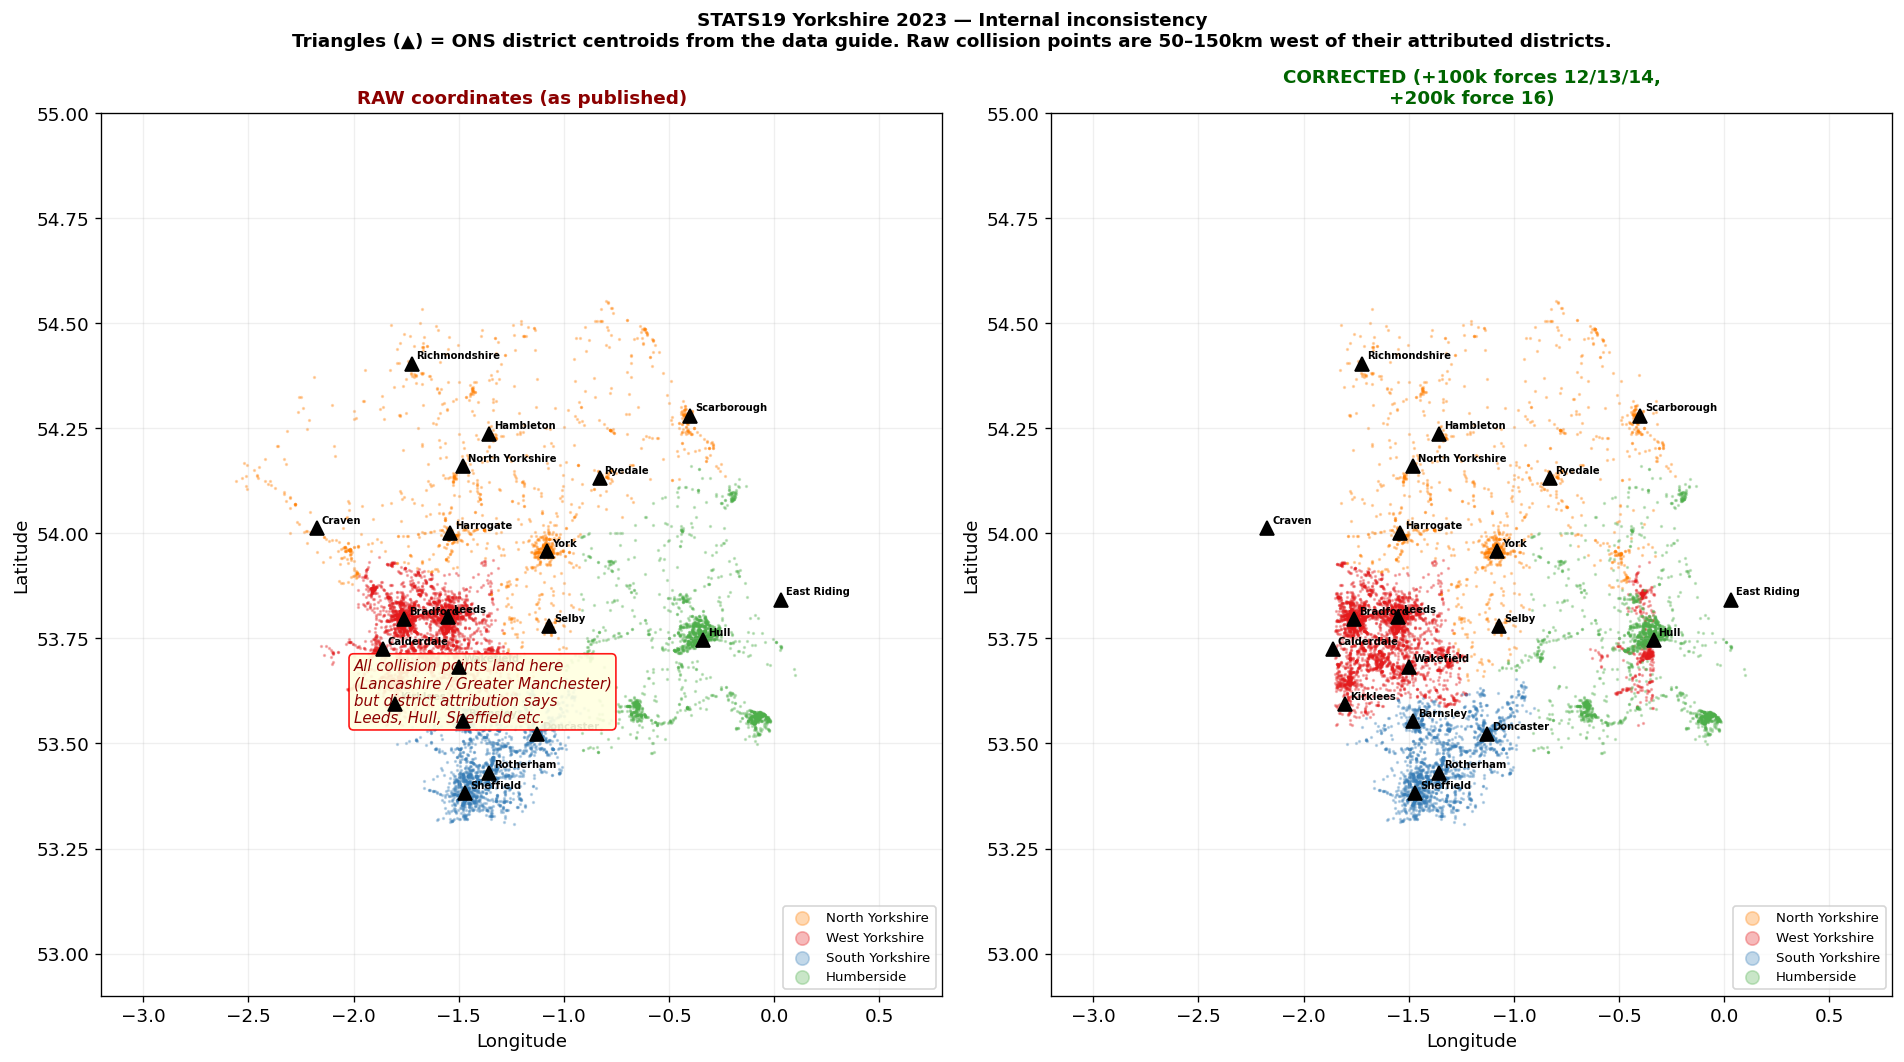

In [36]:
s23 = yorks[
    (yorks['collision_year'] == 2023) & yorks['longitude'].notna()
].copy()

# Apply correction
needs = s23['location_easting_osgr'].notna() & (s23['location_easting_osgr'] < 410_000)
s23['e_corr'] = s23['location_easting_osgr'].copy()
s23['n_corr'] = s23['location_northing_osgr'].copy()
s23.loc[needs & (s23['police_force'] != 16), 'e_corr'] += 100_000
s23.loc[needs & (s23['police_force'] == 16), 'e_corr'] += 200_000

has_bng = s23['e_corr'].notna()
lc, latc = BNG_TO_WGS84.transform(s23.loc[has_bng,'e_corr'].values,
                                    s23.loc[has_bng,'n_corr'].values)
s23.loc[has_bng,'lon_corr'] = lc
s23.loc[has_bng,'lat_corr'] = latc

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
for side, (lon_col, lat_col, title, tc) in enumerate([
    ('longitude','latitude',  'RAW coordinates (as published)',       'darkred'),
    ('lon_corr', 'lat_corr',  'CORRECTED (+100k forces 12/13/14,\n+200k force 16)', 'darkgreen'),
]):
    ax = axes[side]
    for fc, fn in YORKSHIRE_FORCES.items():
        fd = s23[s23['police_force'] == fc]
        ax.scatter(fd[lon_col], fd[lat_col], s=1, alpha=0.3,
                   color=FORCE_COLORS.get(fc,'grey'), label=fn)
    for code, (name, clat, clon) in YORKSHIRE_DISTRICT_CENTROIDS.items():
        ax.plot(clon, clat, 'k^', markersize=8, zorder=5)
        ax.annotate(name, (clon, clat), textcoords='offset points',
                    xytext=(3, 3), fontsize=6, fontweight='bold')
    ax.set_xlim(-3.2, 0.8); ax.set_ylim(52.9, 55.0)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
    ax.set_title(title, fontweight='bold', color=tc, fontsize=11)
    ax.legend(markerscale=8, loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.2)

axes[0].annotate(
    'All collision points land here\n(Lancashire / Greater Manchester)\n'
    'but district attribution says\nLeeds, Hull, Sheffield etc.',
    xy=(-2.0, 53.55), fontsize=9, color='darkred', style='italic',
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='red')
)
plt.suptitle(
    'STATS19 Yorkshire 2023 — Internal inconsistency\n'
    'Triangles (▲) = ONS district centroids from the data guide. '
    'Raw collision points are 50–150km west of their attributed districts.',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 5. Distance improvement after correction, by district

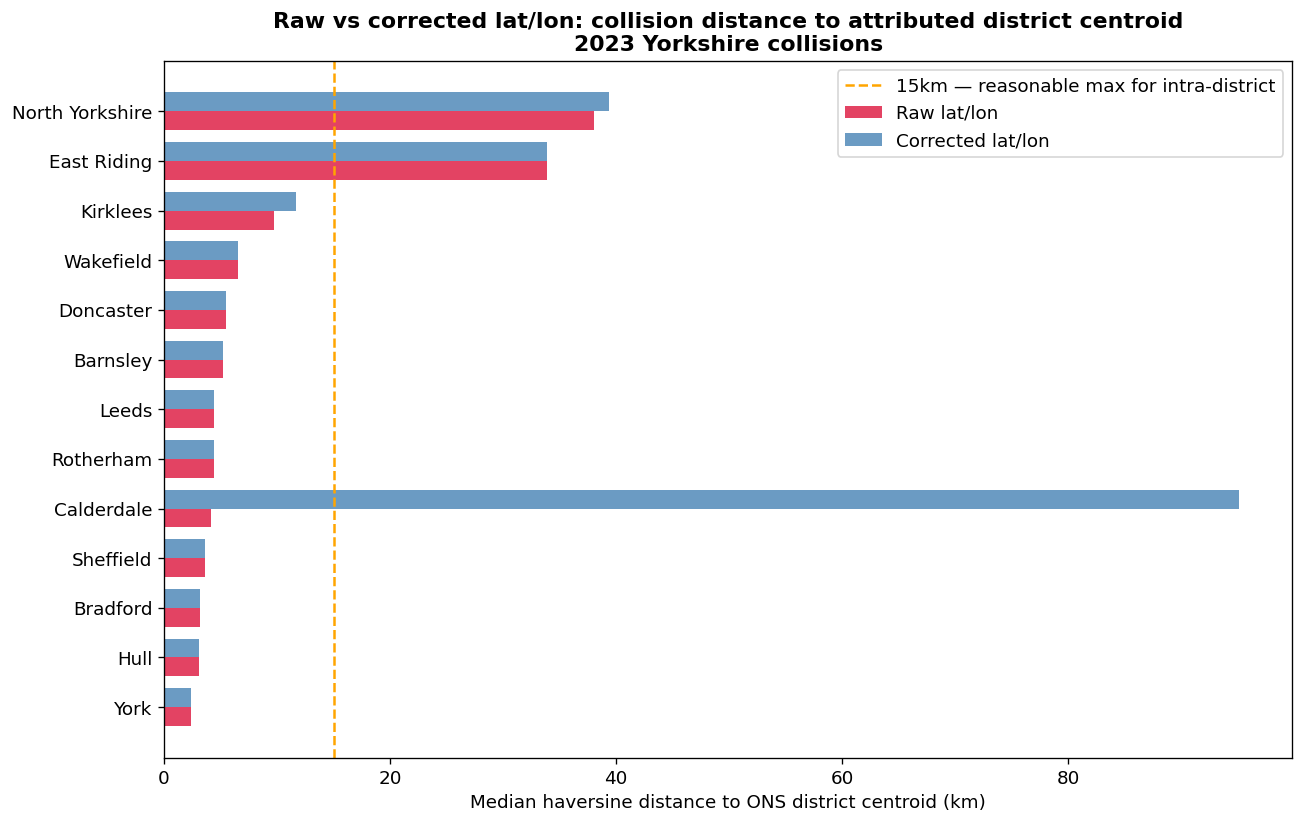

Raw vs corrected median haversine distance per district:
                   raw_km  corrected_km
ons_district_name                      
York                  2.4           2.4
Hull                  3.1           3.1
Bradford              3.2           3.2
Sheffield             3.6           3.6
Calderdale            4.1          95.1
Rotherham             4.4           4.4
Leeds                 4.5           4.5
Barnsley              5.2           5.2
Doncaster             5.5           5.5
Wakefield             6.5           6.5
Kirklees              9.7          11.7
East Riding          33.9          33.9
North Yorkshire      38.0          39.3


In [37]:
# s23 already has centroid_lat/centroid_lon from the yorks merge above
# Compute haversine distances for raw and corrected coordinates
for prefix, loncol, latcol in [('raw', 'longitude', 'latitude'),
                                ('corr', 'lon_corr', 'lat_corr')]:
    m = s23['centroid_lat'].notna() & s23[latcol].notna()
    s23.loc[m, f'dist_{prefix}'] = haversine_km(
        s23.loc[m, latcol].values,  s23.loc[m, loncol].values,
        s23.loc[m, 'centroid_lat'].values, s23.loc[m, 'centroid_lon'].values,
    )

dist_df = (
    s23.dropna(subset=['ons_district_name'])
    .groupby('ons_district_name')[['dist_raw', 'dist_corr']]
    .median()
    .sort_values('dist_raw')
)

fig, ax = plt.subplots(figsize=(11, 7))
x = np.arange(len(dist_df))
w = 0.38
ax.barh(x-w/2, dist_df['dist_raw'],  w, color='crimson',   alpha=0.8, label='Raw lat/lon')
ax.barh(x+w/2, dist_df['dist_corr'], w, color='steelblue', alpha=0.8, label='Corrected lat/lon')
ax.axvline(15, color='orange', linestyle='--', lw=1.5,
           label='15km — reasonable max for intra-district')
ax.set_yticks(x); ax.set_yticklabels(dist_df.index)
ax.set_xlabel('Median haversine distance to ONS district centroid (km)')
ax.set_title('Raw vs corrected lat/lon: collision distance to attributed district centroid\n'
             '2023 Yorkshire collisions', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('Raw vs corrected median haversine distance per district:')
print(dist_df.round(1).rename(
    columns={'dist_raw': 'raw_km', 'dist_corr': 'corrected_km'}).to_string())


## 6. Error consistent across all years 2015–2024

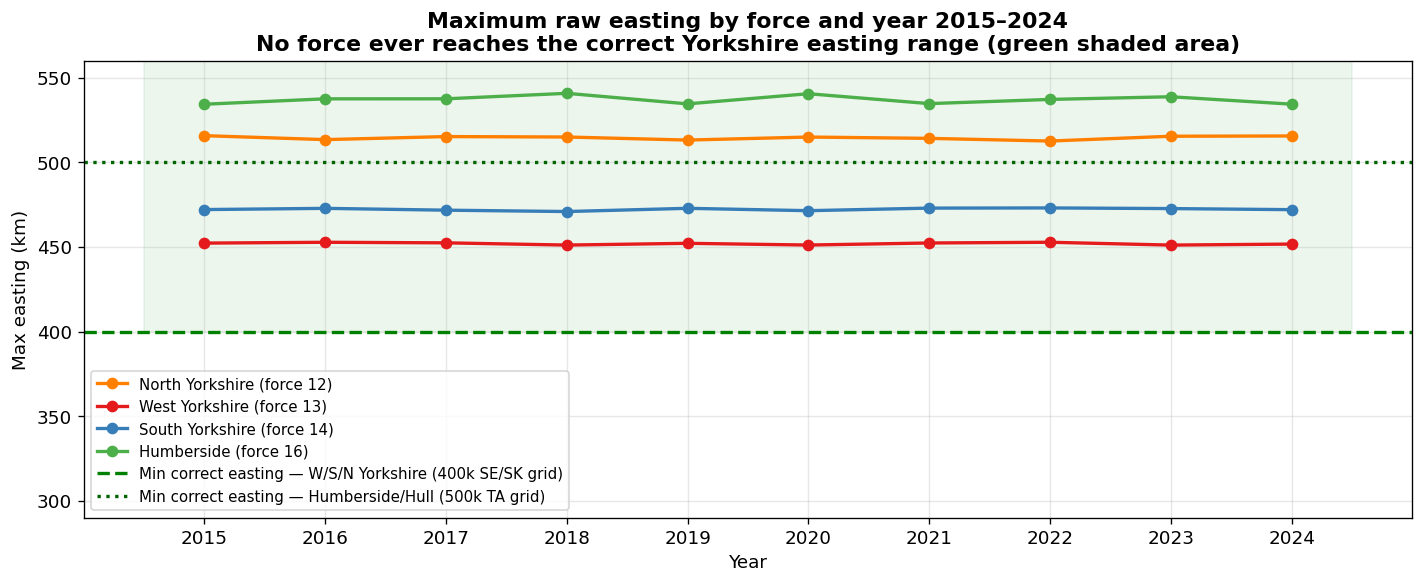

In [38]:
yearly = (
    yorks.groupby(['collision_year','force_name'])['location_easting_osgr']
    .max().reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
for fc, fn in YORKSHIRE_FORCES.items():
    fd = yearly[yearly['force_name'] == fn]
    ax.plot(fd['collision_year'], fd['location_easting_osgr']/1000,
            marker='o', color=FORCE_COLORS[fc], label=f'{fn} (force {fc})', linewidth=2)

ax.axhline(400, color='green', linestyle='--', lw=2,
           label='Min correct easting — W/S/N Yorkshire (400k SE/SK grid)')
ax.axhline(500, color='darkgreen', linestyle=':', lw=2,
           label='Min correct easting — Humberside/Hull (500k TA grid)')
ax.fill_between([2014.5, 2024.5], 400, 600, alpha=0.07, color='green')
ax.set_xlabel('Year'); ax.set_ylabel('Max easting (km)')
ax.set_ylim(290, 560); ax.set_xticks(range(2015, 2025))
ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
ax.set_title('Maximum raw easting by force and year 2015–2024\n'
             'No force ever reaches the correct Yorkshire easting range (green shaded area)',
             fontweight='bold')
plt.tight_layout()
plt.show()